In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, Input

# 1. 데이터 로드 (경로는 본인 환경에 맞게 수정)
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv")
df.columns = df.columns.str.strip()

# [수정] 라벨에 -1을 하지 않습니다. (이미 0, 1인 경우가 많음)
# 만약 라벨이 1, 2라면 1을 빼는 게 맞지만, 에러가 -1로 떴다면 빼면 안 됩니다.
y = df['label']
X = df.drop('label', axis=1)

# 2. 데이터 분할
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. 데이터 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. 모델 구축 (이진 분류용으로 수정)
model = models.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    # [수정] 이진 분류이므로 노드 1개, sigmoid 사용
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    # [수정] 이진 분류용 loss로 변경
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 5. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# 6. 예측 및 결과 분석
y_pred = model.predict(X_test)
# [수정] sigmoid 결과(0~1 사이 확률)를 0.5 기준으로 0 또는 1로 변환
y_pred_class = (y_pred > 0.5).astype(int)

# 7. 시각화 (Loss & Accuracy)
# ... (기존 시각화 코드와 동일) ...

# 8. 최종 리포트
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_class))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7637 - loss: 0.5125 - val_accuracy: 0.9341 - val_loss: 0.3136
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9231 - loss: 0.2520 - val_accuracy: 0.9670 - val_loss: 0.1865
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9533 - loss: 0.1710 - val_accuracy: 0.9670 - val_loss: 0.1375
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9615 - loss: 0.1322 - val_accuracy: 0.9780 - val_loss: 0.1134
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.1143 - val_accuracy: 0.9780 - val_loss: 0.0945
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.0928 - val_accuracy: 0.9780 - val_loss: 0.0838
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.0747 - val_accuracy: 0.9780 - val_loss: 0.0763
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.0671 - val_accuracy: 0.9780 - val_loss

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
clf_lr = LogisticRegression(max_iter=5000)

clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

Logistic Regression
Accuracy: 0.956140350877193
[[45  2]
 [ 3 64]]


In [6]:
clf_svm = SVC()

clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


SVM
Accuracy: 0.9736842105263158
[[45  2]
 [ 1 66]]


In [7]:
clf_dt = DecisionTreeClassifier()

clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


Decision Tree
Accuracy: 0.9035087719298246
[[43  4]
 [ 7 60]]


In [8]:

y = df['mean area']
X = df.drop(['mean area','label'], axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

In [9]:

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression MSE: 314.5940004855177


In [10]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, pred_dt))

Decision Tree MSE: 707.17006993007


In [11]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, pred_rf))

Random Forest MSE: 526.924784860139


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 314.5940004855177
평균제곱근오차 314.5940004855177
평균제곱근오차 314.59400048551777


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_658/3032514812.py:16: SyntaxWarning: invalid decimal literal
  sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))


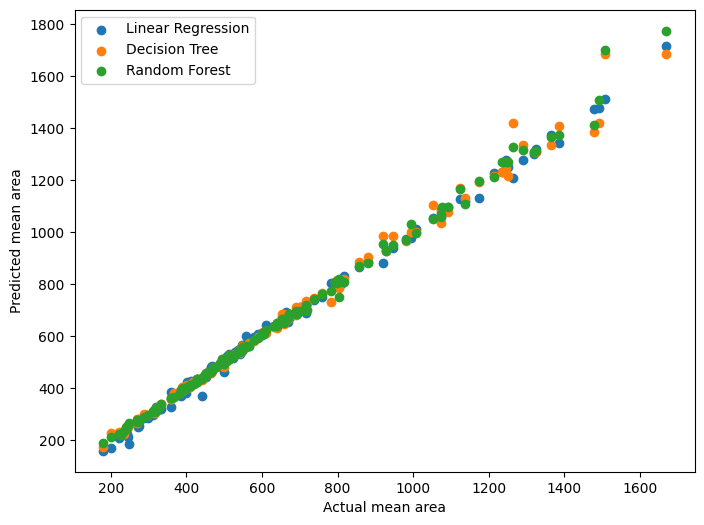

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr, label="Linear Regression")
plt.scatter(y_test, pred_dt, label="Decision Tree")
plt.scatter(y_test, pred_rf, label="Random Forest")

plt.xlabel("Actual mean area")
plt.ylabel("Predicted mean area")

plt.legend()
plt.show()